# Мататематички методи за машинско учење 2025/2026
## Домаћи задатак број 6

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b> Danilo Milošević

<b>Број индекса:</b> 1732
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 06Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [1]:
import numpy as np
import numpy.random as rndm
import matplotlib as mplb
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics.pairwise import rbf_kernel
from scipy.linalg import svd
import time

**Задатак 1.**  У анализи података, Фробенијусова норма мери укупну „енергију” матрице, док нуклеарна норма (норма трага) служи као конвексна апроксимација ранга (нпр. код *Matrix Completion* проблема). Спектрална норма, тј. норма индукована векторском $l_2$ нормом, користи се за процену стабилности алгоритама и нумеричких метода. Повезана је са доминантним структурама у подацима. 

| Норма        | Шта мери?                           | Математички еквивалент                 |
|--------------|--------------------------------------|-----------------------------------------|
| Нуклеарна    | Збир свих сингуарних вредности       | Апроксимација ранга                     |
| Фробенијусова| Квадратни корен збира квадрата       | Укупна енергија / Варијанса             |
| Спектрална   | Највећа сингуарна вредност           | Максимално истезање / Стабилност        |

Посматрајмо матрицу малог ранга $A_0 \in \mathcal{M}_{100 \times 100}$ (нпр. $r=5$) која је контаминирана адитивним Гаусовим шумом $\sigma E$, где су елементи $E_{ij} \sim \mathcal{N}(0, 1),$ тако да је резултујућа матрица $A = A_0 + \sigma E.$

**а)** 
1. Генерисати $A_0$ ранга 5 и шум $E$ тако да је $\|A_0\|_F \approx \sigma \|E\|_F$. Израчунати нуклеарну, Фробенијусову и спектралну норму за $A_0$ и $A$.
2. Проверити теоријску неједнакост: $\|A\|_2 \le \|A\|_F \le \|A\|_N$. 
3. Дискутовати: Која норма је најосетљивија на шум (највише расте релативно у односу на $A_0$)? Прокоментарисати у којим спектралним конфигурацијама су ове неједнакости „оштре” (sharp), а у којим случајевима су „лабаве”.
4. Како се мења спектрална норма $\|A\|_2$ (највећа сингуларна вредност) у односу на $\|A_0\|_2$? Објаснити зашто шум увек „надувава” спектар матрице.

(10 поена)

In [2]:
n = 100
r = 5

U0 = rndm.randn(n, r)
V0 = rndm.randn(n, r)
A0 = U0 @ V0.T
E = rndm.randn(n, n)

norm_A0 = np.linalg.norm(A0, 'fro')
norm_E = np.linalg.norm(E, 'fro')
sigma = norm_A0 / norm_E
A = A0 + sigma * E

print("||A0||_F:", np.linalg.norm(A0, 'fro'))
print("sigma * ||E||_F:", sigma * np.linalg.norm(E, 'fro'))

for mat, naziv in [(A0, "A0"), (A, "A")]:
    U_s, S_s, Vt_s = np.linalg.svd(mat)
    nuc = np.sum(S_s) 
    frob = np.linalg.norm(mat, 'fro')
    spec = S_s[0]
    print(f"\n{naziv}: ||A||_2={spec:.2f} <= ||A||_F={frob:.2f} <= ||A||_N={nuc:.2f}: {spec <= frob <= nuc}")

||A0||_F: 218.201265614977
sigma * ||E||_F: 218.201265614977

A0: ||A||_2=131.18 <= ||A||_F=218.20 <= ||A||_N=476.08: True

A: ||A||_2=135.68 <= ||A||_F=308.65 <= ||A||_N=2208.27: True


Najosetljivija na šum je nuklearna norma, čija se vrednost u primeru iznad drastično povećala. Data nejednakost je oštra u slučaju kada je rang $1$ jer će tada sve norme imati iste vrednosti, pa je nemoguća oštrija nejednakost. Sa druge strane, kada sve singularne vrednosti su slične (npr šum) imamo labavu nejednakost jer će norme imati ogromne razlike, oko $\sqrt{r}$ puta će svaka biti veća, pa je moguća uža nejednakost.

\begin{align*}
\sigma_1 &\approx \sigma_2 \approx \dots \sigma_n\\
\|A\|_2 &= \sigma_{max} \approx \sigma \\
\|A\|_F &= \sqrt{\sum_i^r \sigma_{i}^2} \approx \sqrt{r}\sigma\\
\|A\|_N &= \sum_i \sigma_{i} \approx r\sigma \\
\end{align*}



**б)** 
1. Применити SVD на матрицу $A$. Конструисати серију најбољих апроксимација $A_k$ за $k=1, \dots, 20$. 
2. Нацртати график функције грешке апроксимације $f(k) = \|A - A_k\|_F$. 
3. Пронаћи „колено” (elbow) на графику и повезати га са стварним рангом матрице $A_0$. Дискутовати како интензитет шума $\sigma$ утиче на заобљеност колена и зашто је ова метода често субјективна.

(5 поена)

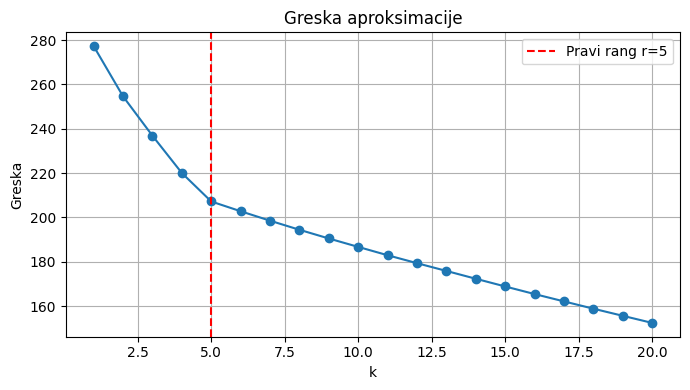

In [3]:
U_a, S_a, Vt_a = np.linalg.svd(A)
greske = [np.linalg.norm(A - U_a[:, :k] @ np.diag(S_a[:k]) @ Vt_a[:k, :], 'fro') for k in range(1, 21)]

plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), greske, 'o-')
plt.axvline(r, color='r', linestyle='--', label=f'Pravi rang r={r}')
plt.xlabel("k")
plt.ylabel("Greska")
plt.title("Greska aproksimacije")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

***

**в) Marchenko-Pastur закон и оптимални праг за PCA:**

Теорија случајних матрица нуди прецизније решење за раздвајање сигнала од шума. За квадратну матрицу димензија $n \times n$ чији су елементи $N(0, \sigma^2)$, Marchenko-Pastur закон предвиђа да ће се сингуларне вредности „чистог шума” налазити унутар опсега чија је горња граница (тзв. *edge*):
$$\lambda_{max} \approx 2 \sigma \sqrt{n}$$
Све сингуларне вредности изнад овог прага сматрају се релевантним сигналом.

1. Извршити SVD матрице $A$. Нацртати хистограм свих сингуларних вредности.
2. На истом графику означити теоријски Marchenko-Pastur праг. 
3. Израчунати нумерички ранг матрице $A$ користећи овај праг. Упоредити добијени број са стварним рангом $A_0$.
4. **Деноисинг:** Конструисати апроксимацију $\tilde{A}$ задржавајући само сингуларне вредности изнад MP прага. Израчунати релативну грешку $\|\tilde{A} - A_0\|_F / \|A_0\|_F$. Дискутовати зашто је ово решење робусније од фиксирања броја компоненти „на слепо”.

(10 поена)

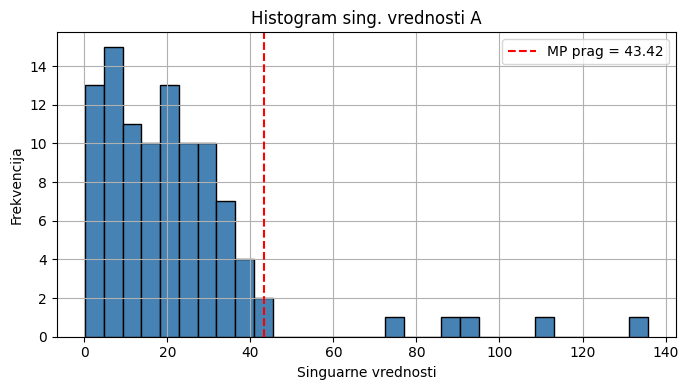

Numericki rang (MP prag): 5, Pravi rang: 5
Relativna greska denoising: 0.3232


In [4]:
lambda_mp = 2 * sigma * np.sqrt(n)
U_a, S_a, Vt_a = np.linalg.svd(A)

plt.figure(figsize=(7, 4))
plt.hist(S_a, bins=30, edgecolor='black', color='steelblue')
plt.axvline(lambda_mp, color='r', linestyle='--', label=f"MP prag = {lambda_mp:.2f}")
plt.xlabel("Singuarne vrednosti")
plt.ylabel("Frekvencija")
plt.title("Histogram sing. vrednosti A")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

r_mp = np.sum(S_a > lambda_mp)
print(f"Numericki rang (MP prag): {r_mp}, Pravi rang: {r}")

A_denoised = U_a[:, :r_mp] @ np.diag(S_a[:r_mp]) @ Vt_a[:r_mp, :]
rel_err = np.linalg.norm(A_denoised - A0, 'fro') / np.linalg.norm(A0, 'fro')
print(f"Relativna greska denoising: {rel_err:.4f}")

Numerički i pravi rang se poklapaju. Relativna greška denoising-a iznosti 32.87%. Ovo rešenje je robustnije od fiksiranja broja komponenti jer radi za različite matrice. Fiksiranjem broja komponenti će možda dati dobre rezultate za konkretan primer na kome testiramo SVD ali će dati gore rezultate u drugi slučajevima, Marchenko-Pastur zakon daje metod izbora broja komponenti koje ćemo zadržati u generalnom slučaju.

***

**Задатак 2.**  Кондициони број и стабилност линеарне регресије

У машинском учењу, проблем најмањих квадрата $\|Ax - b\|_2$ постаје нумерички нестабилан ако су колоне матрице $A$ скоро линеарно зависне (феномен мултиколинеарности). Овај задатак истражује границе машинске тачности кроз призму спектралне декомпозиције.

**а)** Креирати матрицу података $A \in \mathcal{M}_{100 \times 10}$ где је првих 9 колона насумично генерисано из расподеле $\mathcal{N}(0,1)$. Десету колону дефинисати као линеарну комбинацију прве две уз додатак минималног шума: $A_{:, 9} = A_{:, 0} + A_{:, 1} + \epsilon$, где је $\epsilon \sim \mathcal{N}(0, 10^{-k})$. 
- Прокоментарисати како параметар $k$ утиче на утиче на линеарну зависност колона матрице $A.$

(5 поена)

In [5]:
def sim_multikolinearnost(k):
    rndm.seed(42)
    m, p = 100, 10
    A = rndm.randn(m, p)
    eps = rndm.randn(m) * 10**(-k)
    A[:, 9] = A[:, 0] + A[:, 1] + eps
    return A

for k in [2, 7, 14]:
    A = sim_multikolinearnost(k)
    cond = np.linalg.cond(A)
    print(f"k={k}: Uslovljenost = {cond:.2f}")

k=2: Uslovljenost = 309.67
k=7: Uslovljenost = 30987714.90
k=14: Uslovljenost = 309997606915848.19


Sa manjim šumom uslovljenost matrice postaje sve veća. Povećanjem $k$ šum je sve manji pa je poslednja kolona sve bliža linearnoj kombinaciji ostalih kolona.

**б)** Симулирати систем $Ax = b$ тако што ћете дефинисати тачно решење $x_{true} = [1, 1, \dots, 1]^T$ и израчунати десну страну као $b = A x_{true}$. Користећи функцију за решавање система (нпр. `np.linalg.solve`), израчунати нумеричко решење $\hat{x}$.
1. Упоредити грешке $\|\hat{x} - x_{true}\|_2$ за $k=2$ и $k=14$. 
2. Израчунати број изгубљених значајних цифара. 
3. Проверити важење процене: $\text{изгубљене цифре} \approx \log_{10}(\kappa(A))$. Повезати резултате са чињеницом да стандардна *float64* прецизност има око 15–17 значајних децималних цифара.

(10 поена)

In [6]:
x_true = np.ones(10)
for k in [2, 14]:
    A = sim_multikolinearnost(k)
    b = A @ x_true

    x_hat, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    err = np.linalg.norm(x_hat - x_true)
    kappa = np.linalg.cond(A)
    izgubljene_cifre = np.log10(kappa)
    print(f"k={k}: greska={err:.2f}, izgubljene cifre~{izgubljene_cifre:.1f}")

k=2: greska=0.00, izgubljene cifre~2.5
k=14: greska=0.58, izgubljene cifre~14.5


**в)** На основу претходних резултата, написати кратак коментар (5–10 реченица) у коме се:

- објашњава зашто скоро линеарна зависност колона доводи до лоше кондиционираности,
- повезује параметар шума $k$ са геометријом колона матрице $A$,
- интерпретира значење кондиционог броја у контексту стабилности линеарне регресије,
- формулише практична препорука за рад са реалним подацима.

(10 поена)

Kondicioniranost matrice $A$ se može nakon SVD dekompozicije dobiti kao $\kappa = \dfrac{\sigma_{max}}{\sigma_{min}}$. Ukoliko su kolone matrice $A$ skoro linearno zavisne, onda će matrica biti bliska singularnoj, tj imaće malu vrednost $\sigma_{min}$ a time visoku, tj lošu kondicioniranost. Ukoliko je parametar $k$ visok, šum koji dodajemo će biti mali pa će time kolone biti skoro linearno zavisne, pa je time i kondicioniranost veća. Kondicioniranost matrice opisuje stabilnost operacija sa matricom, tj ukolika je kondicioniranost loša, male promene u matricama $A$ ili $b$ će dovesti do velikih promena u vrednsti $x$

Pri radu sa realnim podacima potrebno je proveriti kondicioniranost i ukoliko je loša potencijalno rešenje je Tihonov regularizacija, tj dodati $\lambda$ glavnoj dijagonali kako bi se izbegla linearna zavisnost kolona.

***

**Задатак 3.** У контексту линеарне регресије, решење проблема најмањих квадрата често се тражи преко нормалних једначина: $(A^TA)x = A^Tb$. Овај задатак истражује зашто је овај приступ нумерички ризичан и како регуларизација „лечи” лошу кондиционираност.

**а)** Нека је $A \in \mathcal{M}_{m \times n}$ матрица пуног ранга по колонама. 
1. Користећи SVD декомпозицију матрице $A$, доказати да важи $\kappa(A^TA) = \kappa(A)^2$, где је $\kappa$ кондициони број у спектралној норми.
2. Дискутовати импликације овог резултата: Ако матрица $A$ има кондициони број $10^8$ (што је чест случај у реалним подацима), шта се дешава са стабилношћу система нормалних једначина у стандардној двострукој прецизности? 

(5 поена)

\begin{align*}
A^TA &= (U\Sigma V^T)^TU\Sigma V^T = V\Sigma^T U^T U \Sigma V^T = V\Sigma^T\Sigma V^T\\
&= V\Sigma^2 V^T
\end{align*}
Singularne vrednosti matrice $A^TA$ su $\sigma^2$ pa
\begin{align*}
\kappa (A^TA) = \dfrac{\sigma_{max}^2}{\sigma_{min}^2} = (\dfrac{\sigma_{max}}{\sigma_{min}})^2 = \kappa(A)^2
\end{align*}

Ukoliko matrica $A$ ima kondicioni broj $10^8$ to znači da gubimo 8 značajnih cifara, tako da za normalne jednačine gde se kvadrira kondicioni broj gubili bi 16 značajnih cifara. Rešenja sistema normalnih jednačina bi bila previše neprecizna u standardnoj dvostrukoj preciznosti. 

**б)** Креирати матрицу $A \in \mathcal{M}_{100 \times 10}$ такву да је њена најмања сингуларна вредност $\sigma_{min} = 10^{-6}$ (можете користити SVD конструкцију или методи из Задатка 2).
1. Дефинисати десну страну $b = A x_{true}$.
2. Симулирати малу пертурбацију (грешку мерења или шум) $b \to b + \delta b$, где је $\|\delta b\|_2 = 10^{-3}$.
3. Решити систем нормалних једначина за оригинални и пертурбовани вектор. Измерити релативну промену решења $\|\delta x\|_2 / \|x\|_2$. 
4. Упоредити овај резултат са теоријском границом коју предвиђа $\kappa(A^TA)$. Прокоментарисати стабилност алгоритма.

(10 поена)

In [7]:
m, n = 100, 10
U_c, _ = np.linalg.qr(rndm.randn(m, m))
V_c, _ = np.linalg.qr(rndm.randn(n, n))
S_diag = np.concatenate([np.linspace(10, 1, n-1), [1e-6]])
A = U_c[:, :n] @ np.diag(S_diag) @ V_c.T

x_true = np.ones(n)
b = A @ x_true
delta_b = rndm.randn(m)
delta_b *= 1e-3 / np.linalg.norm(delta_b)

x_orig = np.linalg.solve(A.T @ A, A.T @ b)
x_pert = np.linalg.solve(A.T @ A, A.T @ (b + delta_b))
rel_promena = np.linalg.norm(x_pert - x_orig) / np.linalg.norm(x_orig)

kappa_A = np.linalg.cond(A)
teor_granica = kappa_A**2
print(f"Relativna promena resenja: {rel_promena:.2f}")
print(f"Teorijska granica: {teor_granica:.2f}")


Relativna promena resenja: 31.45
Teorijska granica: 100000000010222.27


**в)** Уводимо параметар регуларизације $\lambda > 0$ и посматрамо систем $(A^TA + \lambda I)x = A^Tb$. Означимо регуларизовану матрицу са $G_\lambda = A^TA + \lambda I$.
1. Како се сингуларне вредности матрице $G_\lambda$ односе према сингуларним вредностима матрице $A^TA$? 
2. Израчунати и нацртати график зависности кондиционог броја $\kappa(G_\lambda)$ од параметра $\lambda$ за $\lambda \in [10^{-9}, 10^1]$. 
3. Анализирати „Bias-Variance Trade-off”: Експериментално показати да повећање $\lambda$ смањује норму решења и његову осетљивост на шум (стабилност), али повећава растојање од тачног решења (пристрасност/bias). Пронаћи $\lambda$ које даје минималну укупну грешку у присуству шума. 

(10 поена)

Kako za simetrične matrice (kao što je $A^TA$) važi da su sopstvene vrednosti jednake singularnim vrednostima. Tada za $A^TA$ važi
$$
Av_i = \lambda_i v_i\\
\lambda_i = \sigma_i^2\\
\Rightarrow A^TAv_i = \sigma_i^2 v_i
$$
Onda
\begin{align*}
Gv_i &= (A^TA+\lambda I)v_i = A^TAv_i + \lambda v_i\\
&= (\sigma^2 + \lambda)v_i
\end{align*}
Odatle vidimo da su singularne vrednosti matrice $G_{\lambda}$ uvećane za $\lambda$ u odnosu na singularne vrednosti matrice $A^TA$.

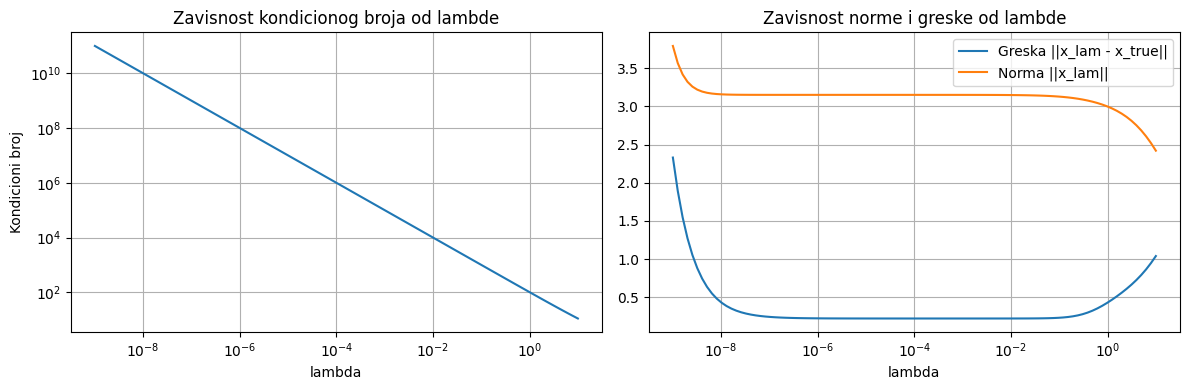

Optimalna lambda: 4.53e-04


In [8]:
lambdas = np.logspace(-9, 1, 100)
kappas = []
greske_x = []
normen_x = []

b_noisy = b + 0.01 * rndm.randn(m)

for lam in lambdas:
    G_lam = A.T @ A + lam * np.eye(n)
    kappas.append(np.linalg.cond(G_lam))
    x_lam = np.linalg.solve(G_lam, A.T @ b_noisy)
    greske_x.append(np.linalg.norm(x_lam - x_true))
    normen_x.append(np.linalg.norm(x_lam))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(lambdas, kappas)
axes[0].set_xlabel("lambda"); axes[0].set_ylabel("Kondicioni broj")
axes[0].set_title("Zavisnost kondicionog broja od lambde")
axes[0].grid(True)

axes[1].semilogx(lambdas, greske_x, label='Greska ||x_lam - x_true||')
axes[1].semilogx(lambdas, normen_x, label='Norma ||x_lam||')
axes[1].set_xlabel("lambda"); axes[1].legend()
axes[1].set_title("Zavisnost norme i greske od lambde")
axes[1].grid(True)
plt.tight_layout()
plt.show()
best_lam = lambdas[np.argmin(greske_x)]
print(f"Optimalna lambda: {best_lam:.2e}")

Povećanjem vrednosti $\lambda$ se smanjuje kondicioni broj pa se poboljšava stabilnost i smanjuje norma rešenja. Povećanjem $\lambda$ prvo opada greška rezultata ali povećanjem iznad $1$ se opet povećava greška.

**г)** На основу претходних тачака, кратко одговорити: 
- Зашто се у нумеричким библиотекама (нпр. `scipy.linalg.lstsq`) избегава директно решавање нормалних једначина и уместо тога користи QR или SVD декомпозиција матрице $A$?
- Како регуларизација геометријски деформаише јединични елипсоид мапе $A^TA$ да би га учинила „сферичнијим”? (10 поена)

U numeričkim bibliotekama se izbegava rešavanje normalnih jednačina jer se time povećava kondicionalnost i rešenja su neprecizna. Da bi se izbegao gubitak preciznosti na ovaj način koristi se QR ili SVD dekompozicija matrice $A$.



***

**Задатак 3.** Ортогонални Прокрустов проблем

У многим задацима вештачке интелигенције (нпр. *Domain Adaptation* или поравнање векторских простора различитих језика), срећемо се са проблемом где два скупа података имају исту унутрашњу структуру, али су приказани у различитим координатним системима. Прокрустова анализа је најбољи линеарни метод за поравнање таквих структура чувајући њихову геометрију.

**а)** 1. Генерисати скуп података $X \in \mathcal{M}_{200 \times 2}$ (нпр. тачке које формирају препознатљив облик или кластере). 
2. Креирати $Y = XR + E$, где је $R$ случајно генерисана ортогонална матрица ротације, а $E$ матрица Гаусовог шума $\mathcal{N}(0, \sigma^2)$.
3. Решити Прокрустов проблем и пронаћи оптимално $\hat{Q}$.
4. Користећи особину инваријантности Фробенијусове норме на ортогоналне трансформације, разложити укупну грешку поравнања на део настао услед шума и део настао услед несавршене ротације. Визуелизовати оригинални скуп $X$, циљни скуп $Y$ и поравнати скуп $X\hat{Q}$. 

(10 поена)

Ukupna kvadratna greska: 33.12
Kvadratna greska suma: 33.13


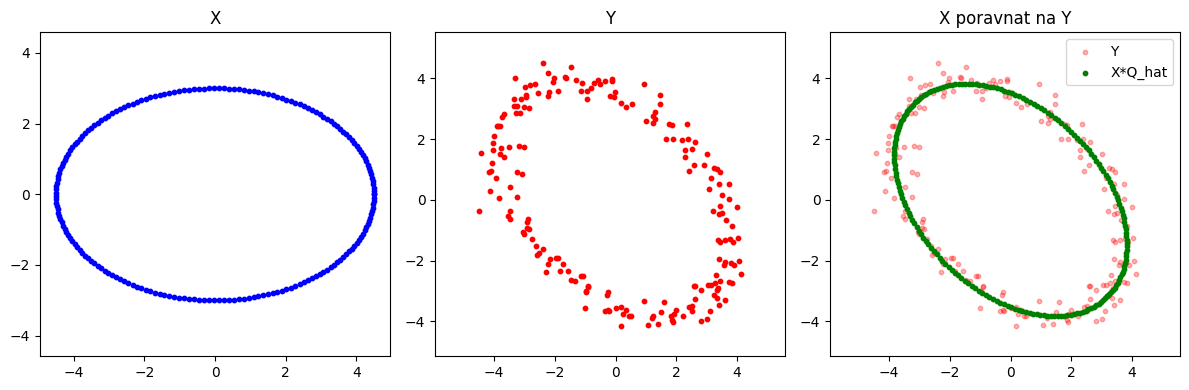

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rndm = np.random.RandomState(42)
N_pts = 200
theta = np.linspace(0, 2*np.pi, N_pts)
X = np.column_stack([np.cos(theta), np.sin(theta)]) * 3
X[:, 0] = X[:, 0] * 1.5 # elipsa

angle = np.pi / 4
R_true = np.array([[np.cos(angle), -np.sin(angle)], 
                   [np.sin(angle), np.cos(angle)]])

sigma_E = 0.3
E = sigma_E * rndm.randn(N_pts, 2)
Y = X @ R_true + E

M = X.T @ Y
U, S, Vt = np.linalg.svd(M)
Q_hat = U @ Vt

X_aligned = X @ Q_hat

total_error = np.linalg.norm(X_aligned - Y, 'fro')**2
noise_error = np.linalg.norm(E, 'fro')**2

print(f"Ukupna kvadratna greska: {total_error:.2f}")
print(f"Kvadratna greska suma: {noise_error:.2f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c='blue', s=10)
plt.title("X")
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.scatter(Y[:, 0], Y[:, 1], c='red', s=10)
plt.title("Y")
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.scatter(Y[:, 0], Y[:, 1], c='red', s=10, alpha=0.3, label='Y')
plt.scatter(X_aligned[:, 0], X_aligned[:, 1], c='green', s=10, label='X*Q_hat')
plt.title("X poravnat na Y")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

**б) Прокруст vs. Линеарна регресија (Критичка анализа):**
1. Решити исти проблем поравнања користећи обичну линеарну регресију (без ограничења на ортогоналност матрице трансформације): $XW = Y \Longrightarrow W = (X^TX)^{-1}X^TY$.
2. Упоредити грешке поравнања $\|X\hat{Q} - Y\|_F$ и $\|XW - Y\|_F$. Који метод даје мању грешку на тренинг подацима?
3. Дискутовати геометријске последице: Шта трансформација $W$ ради подацима што Прокрустова трансформација $Q$ не сме (нпр. скалирање, смицање)? Зашто је у AI задацима поравнања простора значења (нпр. *cross-lingual mapping*) често пожељније користити ортогонално поравнање упркос нешто већој грешци? 

(10 поена)

Greska linearne regresije: 5.7197
Prokrustova greska: 33.1190


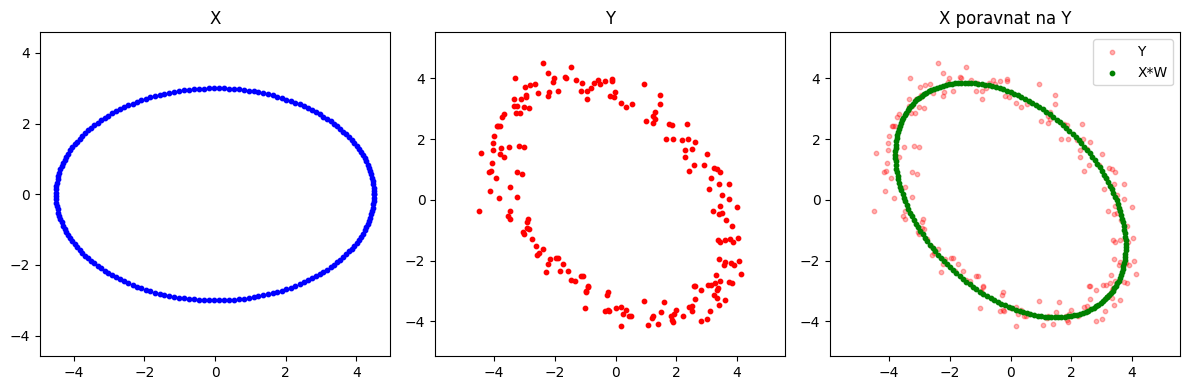

In [10]:
W = np.linalg.solve(X.T @ X, X.T @ Y)
greska_lr = np.linalg.norm(X @ W - Y, 'fro')
print(f"Greska linearne regresije: {greska_lr:.4f}")
print(f"Prokrustova greska: {total_error:.4f}")
X_aligned = X@W

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c='blue', s=10)
plt.title("X")
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.scatter(Y[:, 0], Y[:, 1], c='red', s=10)
plt.title("Y")
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.scatter(Y[:, 0], Y[:, 1], c='red', s=10, alpha=0.3, label='Y')
plt.scatter(X_aligned[:, 0], X_aligned[:, 1], c='green', s=10, label='X*W')
plt.title("X poravnat na Y")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()


Prokrustova transformacija $Q$ je ortogonalna matrica, što znači da je u stanju da samo rotira i reflektuje podatke. Sa druge strane matrica $W$ može da vrši i skaliranje i smicanje.

Kod AI zadataka je bitno očuvati relativne odnose između podataka kao što su uglovi između vektora podataka. Smicanjem i skaliranjem matrica $W$ može poremetiti odnose, pa zato iako ima manju grešku često nije dobar izbor kod AI zadataka. Pored toga, usled mnogo više stepena slobode (s obzirom da ima više transformacija nego kod Prokrustove) može dovesti do overfittinga.

**в) Растезање израза и уочавање проблема (Аналитички део):**
1. Развити израз $\|QXU - Y\|_F^2$ користећи особине трага. Доказати да је минимизација овог израза еквивалентна максимизацији функције $f(Q, U) = {\rm tr}(Q X U Y^T)$.
2. Објаснити зашто решење из материјала ($Q = V W^T$ за $X^TY = V\Sigma W^T$) овде не може директно да се примени. У чему се огледа „спрегнутост” (coupling) матрица $Q$ и $U$ у овом изразу? 

(5 поена)

**г) Пут ка решењу преко SVD декомпозиција (Истраживачки део):**
Уместо рачунања SVD-а производа, размотримо појединачне SVD декомпозиције:
$$X = U_X \Sigma_X V_X^T \quad \text{и} \quad Y = U_Y \Sigma_Y V_Y^T$$
1. Интуитивно објаснити: Ако желимо да матрица $X$ „личи” на $Y$, шта би оптималне трансформације $Q$ и $U$ требало да ураде са главним правцима (сингуларним векторима) матрице $X$ у односу на главне правце матрице $Y$?
2. Користећи ову интуицију, предложити форме за $Q$ и $U$ преко матрица сингуларних вектора $U_X, U_Y, V_X, V_Y$. 

(10 поена)

Želimo da pomoću matrica $Q$ i $U$ poravnamo pravce matrica $X$ i $Y$. Optimalne transformacije $Q$ i $U$ bi trebale da poravnaju singularne vektore ovih matrica
\begin{align*}
QXU &= Y \\
QU_X \Sigma_X V_X^TU &= U_Y \Sigma_Y V_Y^T\\
&\Rightarrow QU_X = U_Y,\, V_X^TU = V^Y_T\\
Q &= U_YU_X^T\\
U &= V_XV_Y^T
\end{align*}

**д) Нумеричка верификација и Клетва знака:**
1. Генерисати случајне матрице $X$ и $Y$ димензија $10 \times 10$. Израчунати оптималне $Q$ и $U$ преко предложене методе из тачке (б).
2. Израчунати вредност $\|QXU - Y\|_F$. 
3. **Изазов:** Код овог проблема постоји скривена замка — сингуларни вектори су дефинисани до на знак ($\pm u_i$). Како насумичан избор знака у SVD алгоритму може покварити поравнање? Предложити једноставну хеуристику како бисте осигурали да сингуларни вектори буду „кохерентно” оријентисани пре него што формирате $Q$ и $U$. 

(10 поена)

In [11]:
X = np.random.randn(10, 10)
Y = np.random.randn(10, 10)

Ux, Sx, Vxt = np.linalg.svd(X, full_matrices=False)
Uy, Sy, Vyt = np.linalg.svd(Y, full_matrices=False)
Vx = Vxt.T

Q = Uy @ Ux.T
U = Vx @ Vyt

err = np.linalg.norm(Q @ X @ U - Y, ord='fro')

print(err)

1.292835192108551


Problem nastaje kada vektori u $X$ i $Y$ imaju iste pravce ali suprotne smerove. Tada će ova metoda pogrešno zaključiti da je potrebno zarotirati vektor za 180 stepeni. Jedno rešenje je odrediti skalarne proizvode kolona u $U_X$ i $U_Y$ i pomnožiti kolone u $U_X$ i $V_X$. Znak će biti $1$ ako su istog pravca i smera a $-1$ ako su istog pravca a suprotnog smera. Množenjem $U$ i $V$ za matricu $X$ dovodimo ih na isti smer.

In [12]:
X = np.random.randn(10, 10)
Y = np.random.randn(10, 10)

Ux, Sx, Vxt = np.linalg.svd(X)
Uy, Sy, Vyt = np.linalg.svd(Y)
Vx = Vxt.T

signs = np.sign(np.sum(Ux * Uy, axis=0))
Ux *= signs
Vx *= signs

Q = Uy @ Ux.T
U = Vx @ Vyt

err = np.linalg.norm(Q @ X @ U - Y, ord='fro')

print(err)

1.5776930780188856


***

**Задатак 4.**  Како победити „Клетву димензионалности”: Nyström апроксимација

У многим алгоритмима машинског учења (као што су SVM или Kernel PCA), уместо са оригиналним подацима $x \in \mathbb{R}^d$, радимо са њиховим нелинеарним пресликавањима у простор веће димензије $\phi(x)$. Главна предност овог приступа је **Кернел трик**: уместо експлицитног рачунања $\phi(x)$, израчунавамо само скаларни производ у том простору преко кернел функције: $\kappa(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$.

За скуп од $N$ података формирамо Кернел матрицу (Грамову матрицу) $K \in \mathcal{M}_{N \times N}$, где је сваки елемент $K_{ij}$ мера сличности између тачака $i$ и $j$. Најчешће коришћени је **RBF кернел**:
$$K_{ij} = \exp\!\left(-\gamma \,\lVert x_i - x_j \rVert^{2}\right)$$

У раду са великим подацима ($N > 10^5$), израчунавање пуне кернел матрице $K \in \mathcal{M}_{N \times N}$ и њене спектралне декомпозиције (за Kernel PCA) је рачунски немогуће због сложености $O(N^3)$. Решење је апроксимација малог ранга заснована на подскупу података.

**Контекст:** Поделимо податке на скуп „оријентира” (landmarks, $m$ тачака) и остатак ($n-m$ тачака), где је $m \ll n$. Матрицу $K$ записујемо у блок форми:
$$K = \begin{bmatrix} 
W & B \\ 
B^T & C 
\end{bmatrix}$$
где је $W \in \mathcal{M}_{m \times m}$ сличност међу оријентирима, а $B \in \mathcal{M}_{m \times (n-m)}$ сличност између оријентира и осталих тачака.

**а) Конструкција „уског грла” (Bottleneck):** 
Nyström апроксимација претпоставља да се блок $C$ може апроксимирати користећи само информације из блокова $W$ и $B$ као $\tilde{C} = B^T W^{-1} B$. 
1. Доказати да се тада цела апроксимирана матрица $\tilde{K}$ може записати у факторисаном облику:
$$\tilde{K} = \begin{bmatrix} W \\ B^T \end{bmatrix} W^{-1} \begin{bmatrix} W & B \end{bmatrix}$$
2. Који је максимални могући ранг матрице $\tilde{K}$? Повежите ово са идејом компресије података. 

(5 поена)

\begin{align*}
\tilde{K} &= \begin{bmatrix} W \\ B^T \end{bmatrix} W^{-1} \begin{bmatrix} W & B \end{bmatrix} \\
\tilde{K} &= \begin{bmatrix} I \\ B^T W^{-1}\end{bmatrix}\begin{bmatrix} W & B \end{bmatrix}\\
\tilde{K} &= \begin{bmatrix} W & B \\ B^T W^{-1} W & B^TW^{-1}B\end{bmatrix} \\
\tilde{K} &= \begin{bmatrix} W & B \\ B^T & B^TW^{-1}B\end{bmatrix} \\
\end{align*}

Možemo da zaključimo
\begin{align*}
rank(ABC) &\leq min(rank(A), rank(B), rank(C))\\
\Rightarrow rank(\tilde{K}) &\leq min(rank(\begin{bmatrix} W \\ B^T \end{bmatrix}), rank(W^{-1}), rank(\begin{bmatrix} W & B \end{bmatrix}))
\end{align*}

Ako $W$ nije singularna matrica, onda je
\begin{align*}
rank(W) &= rank(W^-1) = m\\
rank(\begin{bmatrix} W \\ B^T \end{bmatrix}) &\leq m\\
rank(\begin{bmatrix} W & B \end{bmatrix}) &\leq m\\
\\
\Rightarrow rank(\tilde{K}) &\leq min(k, k, k)\\
\boxed{rank(\tilde{K}) \leq k }
\end{align*}

**б) Нумеричка имплементација и ефикасност:**
Уместо инверза $W^{-1}$ (који може бити нестабилан), користимо Мур-Пенроуз псеудоинверз $W^+$.
1. Генерисати нелинеаран скуп података (нпр. концентрични кругови или „месеци” из `sklearn.datasets`) са $N=1000$ тачака.
2. Изабрати насумично $m=50$ тачака као оријентире.
3. Израчунати апроксимацију $\tilde{K} = K_{nm} W^+ K_{nm}^T$, где је $K_{nm} = \begin{bmatrix} W \\ B^T \end{bmatrix}$.
4. Измерити време потребно за рачунање SVD декомпозиције пуне матрице $K$ у односу на апроксимацију $\tilde{K}$ (дискутовати зашто је за велике $N$ разлика огромна).

(10 поена)

In [13]:
N = 3000
X, _ = make_moons(n_samples=N, noise=0.1, random_state=42)

m = 50
indices = np.random.choice(N, m, replace=False)
X_m = X[indices]


W = rbf_kernel(X_m, X_m)
B_T = rbf_kernel(X[np.setdiff1d(np.arange(N), indices)], X_m)
K_nm = np.vstack([W, B_T])

start = time.time()
W_inv = np.linalg.pinv(W)
K_tilde = K_nm @ W_inv @ K_nm.T
time_calc = time.time() - start

K_full = rbf_kernel(X, X)

start = time.time()
svd(K_full)
time_full_svd = time.time() - start
print(f"Vreme za SVD za K ({N}x{N}): {time_full_svd:.4f} s")

start = time.time()
svd(K_tilde)
time_approx_svd = time.time() - start
print(f"Vreme za SVD za K_tilde ({N}x{N}): {time_approx_svd:.4f} s")

Vreme za SVD za K (3000x3000): 10.1570 s
Vreme za SVD za K_tilde (3000x3000): 8.6710 s


**в) Анализа квалитета (Frobenius vs Eckart-Young):**

1. Израчунати грешку апроксимације у Фробенијусовој норми: $E_{nys} = \|K - \tilde{K}\|_F$.
2. Користећи Eckart-Young-Mirsky теорему, израчунати теоријски минималну могућу грешку апроксимације ранга $m$ за матрицу $K$: $E_{min} = \|K - K_m\|_F$.
3. Упоредити $E_{nys}$ и $E_{min}$. Дискутовати: зашто у пракси прихватамо нешто већу грешку Nyström методе? Како избор „оријентира” (насумично vs. $k$-means центроиди) може утицати на то да се $E_{nys}$ приближи вредности $E_{min}$? 

(10 поена)

***

**Задатак 5.** Класификација цифара методом потпростора (MNIST)

У овом задатку истражујемо моћ моделовања класа као потпростора ниске димензије. Циљ је да се превазиђе обичан PCA приступ увођењем трансформације која мапира потпросторе тако да они постану „што више ортогонални” једни на друге.

**а)** 
1. Из MNIST базе издвојити податке за цифре {0, 1, 4, 8, 9}. Поделити податке на тренинг и тест скуп (нпр. 80/20%).
2. За сваку класу израчунати средњи вектор $\mu_i$ и матрицу ортонормиране базе $U_i \in \mathcal{M}_{784 \times k}$ користећи првих $k=20$ главних компоненти центрираних података те класе. 
3. Визуелизовати првих 5 главних компоненти за цифре 4 и 9. Прокоментарисати сличности у њиховим спектралним структурама.

(5 поена)

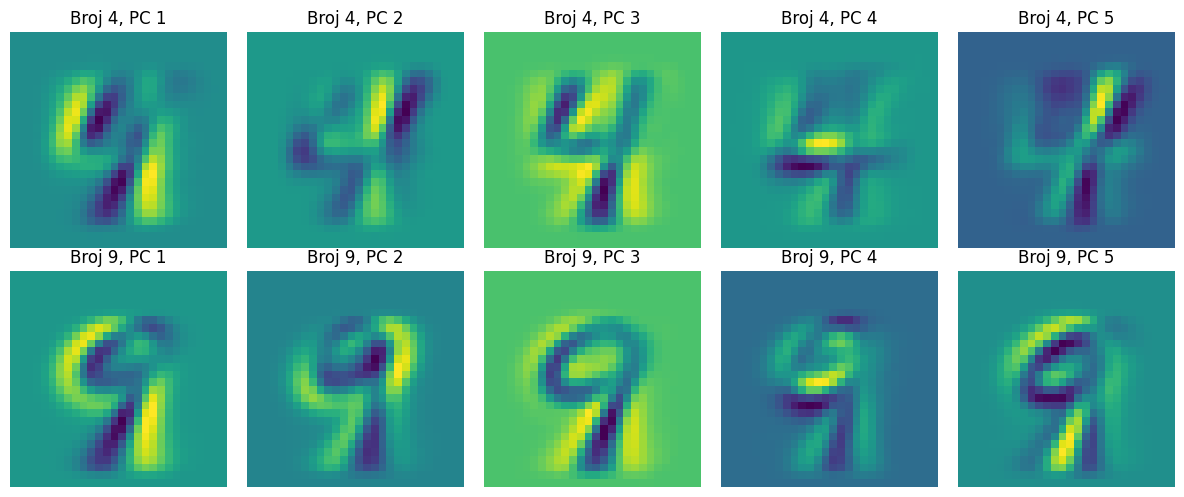

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

digits = [0, 1, 4, 8, 9]
mask = np.isin(y, digits)
X_filtered = X[mask] / 255.0
y_filtered = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

k = 20
calc = {}

for d in digits:
    X_d = X_train[y_train == d]
    mu_d = np.mean(X_d, axis=0)
    X_centered = X_d - mu_d
    
    _, _, Vt = svd(X_centered, full_matrices=False)
    calc[d] = {'mu': mu_d, 'U': Vt[:k].T}

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, d in enumerate([4, 9]):
    U_d = calc[d]['U']
    for j in range(5):
        ax = axes[i, j]
        comp = U_d[:, j].reshape(28, 28)
        im = ax.imshow(comp)
        ax.set_title(f"Broj {d}, PC {j+1}")
        ax.axis('off')

plt.tight_layout()
plt.show()

Postoje sličnosti u njihovim spektralnim strukturama s obzirom na sličnosti u topologiji zapisa broja - kosi potez sa otvorenom petljom kod 4 i zatvorenom kod 9.

**б)** 
1. За сваку слику $v$ из тест скупа, израчунати пројекције на сваки од 5 потпростора: $v_{proj, i} = U_i U_i^T (v - \mu_i)$.
2. Израчунати Еуклидско растојање (резидуал) до сваког потпростора: $d_i(v) = \|(v - \mu_i) - v_{proj, i}\|_2$.
3. Класификовати тест слике на основу минималног растојања и приказати матрицу конфузије.

(5 поена)

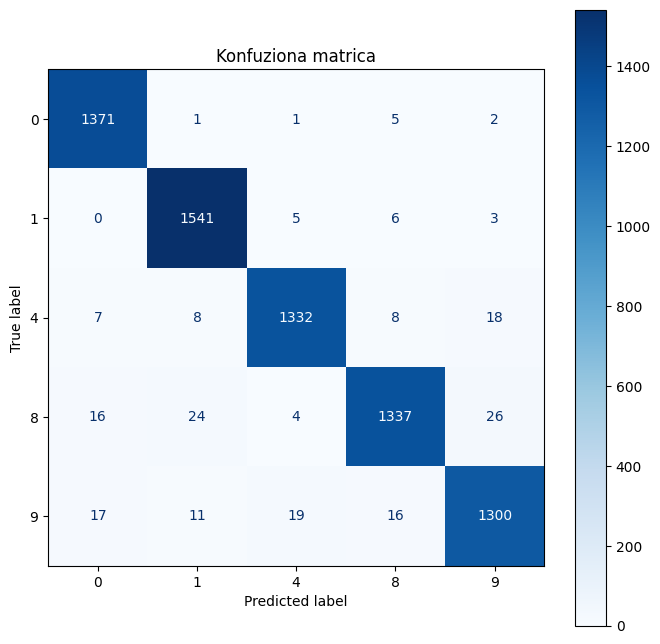

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = []

for v in X_test:
    dist = []
    
    for d in digits:
        mu_i = calc[d]['mu']
        U_i = calc[d]['U']
        
        v_centered = v - mu_i
        
        v_proj = U_i @ (U_i.T @ v_centered)
        
        err = v_centered - v_proj
        d = np.linalg.norm(err)
        dist.append(d)

    best_digit_idx = np.argmin(dist)
    y_pred.append(digits[best_digit_idx])

y_pred = np.array(y_pred)

cm = confusion_matrix(y_test, y_pred, labels=digits)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Konfuziona matrica")
plt.show()

**в)** 
1. Идентификовати две цифре које се најчешће мешају (нпр. 4 и 9).
2. Израчунати каноничке углове између њихових потпростора $U_4$ и $U_9$ (сингуларне вредности матрице $U_4^T U_9$). 
3. Колико каноничких углова је близу нуле (тј. $\cos \theta \approx 1$)? Објаснити везу између ових углова и грешака у матрици конфузије.

(5 поена)

In [30]:
from scipy.linalg import svdvals
d1, d2 = 4, 9

U1 = calc[d1]['U']
U2 = calc[d2]['U']
cos_thetas = svdvals(U1.T @ U2)

angles_deg = np.rad2deg(np.arccos(cos_thetas))

print(f"Uglovi: {angles_deg}")

close_to_zero = np.sum(cos_thetas > 0.9)
print(f"Broj uglova blizu nule: {close_to_zero}")

Uglovi: [ 8.59749383  9.74898412 14.97700005 15.16361697 16.49131709 20.5707535
 21.23222992 24.5610528  27.36838095 28.53536851 30.93247302 37.97947494
 40.58915063 44.38679383 53.11543565 60.99550213 66.73281918 71.3500452
 76.04977642 83.67614402]
Broj uglova blizu nule: 8


**г)** SDA трансформација и побољшање сепарабилности:
1. Формирати матрице расипања $S_b$ и $S_w$.
2. Решити уопштени сопствени проблем $S_b w = \lambda S_w w$ (користећи „избељивање” простора или регуларизацију $S_w + \epsilon I$ како би инверзија била стабилна).
3. Одабрати матрицу трансформације $W$ састављену од првих $d=50$ уопштених сопствених вектора.
4. Трансформисати базе потпростора: $\tilde{U}_i = {\rm orth}(W^T U_i)$.
5. Поново израчунати каноничке углове између трансформисаних потпростора за цифре 4 и 9. Доказати нумерички да су углови сада већи (косинуси мањи) и дискутовати како ово директно помаже класификацији.

(10 поена)

***